# Система обнаружения стеганографии с помощью GSR-Net

**Архитектура:** GSR-Net — ResNet-блоки с механизмом Squeeze-and-Excitation (SE-блоки)  
**Данные:** RGB, 256×256, LSB-replacement, Cover=2000, Stego=2000  
**Оценка:** 5-Fold Stratified Cross-Validation  

Особенности реализации:
- HPF-слой (фильтр Кёнига 5×5, 3→64 канала) + BN + Tanh + Abs
- 4 GSRBlock (ResNet-блок + SE-блок): остаточные связи + канальное внимание
- SE-блок (reduction=4): Squeeze → GAP → FC → ReLU → FC → Sigmoid → Scale
- BCEWithLogitsLoss + Adam + CosineAnnealingLR + gradient clipping
- Аугментации: HFlip, VFlip (без RandomRotation — сохраняем LSB-сигнал)
- Нормализация: ToTensor() [0,1] без ImageNet-нормализации

**Принцип SE-блока:**  
Squeeze: GlobalAvgPool → вектор [B, C] — глобальная статистика каждого канала.  
Excitation: FC(C→C//4) → ReLU → FC(C//4→C) → Sigmoid → веса [B, C, 1, 1].  
Scale: исходные карты признаков × веса → усиление значимых каналов.  
В отличие от Split-Attention (Zhu-Net), SE работает на уровне каналов,
а не ветвей, что даёт меньше параметров при сопоставимой эффективности.


In [2]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# 1. Импорт библиотек
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)


In [4]:
# 2. Воспроизводимость и проверка GPU
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')


Используемое устройство: cuda


In [5]:
# 3. Конфигурация данных и папки сохранения
COVER_DIR = '/content/drive/MyDrive/FQW/Stego-Images_clean6000/'
STEGO_DIR = '/content/drive/MyDrive/FQW/Stego-Images_stego6000/'
IMG_SIZE = 256
MAX_IMAGES_PER_CLASS = 2000  # Cover=2000, Stego=2000

# Папка для сохранения всех артефактов
SAVE_DIR = '/content/drive/MyDrive/FQW/gsrnet2000'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Папка для сохранения: {SAVE_DIR}')

# Сбор путей к файлам (не грузим в память — экономим RAM)
cover_imgs = sorted([
    os.path.join(COVER_DIR, f) for f in os.listdir(COVER_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:MAX_IMAGES_PER_CLASS]

stego_imgs = sorted([
    os.path.join(STEGO_DIR, f) for f in os.listdir(STEGO_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:MAX_IMAGES_PER_CLASS]

print(f'Загружено путей: Cover={len(cover_imgs)}, Stego={len(stego_imgs)}')

# Глобальные списки — используются в skf.split() на каждой итерации CV
images = cover_imgs + stego_imgs
labels = [0] * len(cover_imgs) + [1] * len(stego_imgs)

# Разбиение 80/20
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=SEED, stratify=labels
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Train: Cover={y_train.count(0)}, Stego={y_train.count(1)}')
print(f'Test:  Cover={y_test.count(0)},  Stego={y_test.count(1)}')


Папка для сохранения: /content/drive/MyDrive/FQW/gsrnet2000
Загружено путей: Cover=2000, Stego=2000
Train: 3200, Test: 800
Train: Cover=1600, Stego=1600
Test:  Cover=400,  Stego=400


In [6]:
# 4. Dataset и DataLoader
class StegDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths   = paths
        self.labels  = labels
        self.augment = augment

        # Нормализация: только ToTensor() → [0, 1]
        self.base_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),  # [0, 1]
        ])

        # Аугментации: только флипы — не меняют значения пикселей
        self.train_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')  # RGB — 3 канала
        if self.augment:
            img = self.train_transform(img)
        else:
            img = self.base_transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

# Проверка корректности загрузки
test_ds = StegDataset(images[:4], labels[:4], augment=False)
x, y = test_ds[0]
print(f'Размер тензора: {x.shape}, dtype: {x.dtype}, диапазон: [{x.min():.3f}, {x.max():.3f}]')
print(f'Метка: {y}')


Размер тензора: torch.Size([3, 256, 256]), dtype: torch.float32, диапазон: [0.000, 0.957]
Метка: 0.0


In [7]:
# 5. Архитектура GSR-Net (с SE-блоками и остаточными связями)

# Структура:
#   HPF (3→64, kernel=5) + BN + Tanh + Abs   ← выделение шумового остатка
#   GSRBlock(64→64,   stride=1)               ← разрешение не меняется
#   GSRBlock(64→128,  stride=2)               ← 256×256 → 128×128
#   GSRBlock(128→256, stride=2)               ← 128×128 → 64×64
#   GSRBlock(256→512, stride=2)               ← 64×64   → 32×32
#   AdaptiveAvgPool2d(1) → Flatten
#   Dropout(0.3) → Linear(512, 1)

# SE-блок (reduction=4):
#   Squeeze:   GAP → [B, C]
#   Excitation: FC(C→C//4) → ReLU → FC(C//4→C) → Sigmoid → [B, C, 1, 1]
#   Scale:      x * weights — усиление информативных каналов
#
# GSRBlock = Conv→BN→ReLU→Conv→BN → SE → + residual → ReLU

def init_king_weights_gsrnet(layer):
    """
    Инициализация HPF-слоя фильтром Кёнига 5×5.
    3 входных RGB-канала → 64 выходных фильтра.
    Замораживается после warmup-эпох.
    """
    ker = np.array([
        [-1,  2, -2,  2, -1],
        [ 2, -6,  8, -6,  2],
        [-2,  8, -12,  8, -2],
        [ 2, -6,  8, -6,  2],
        [-1,  2, -2,  2, -1]
    ], dtype=np.float32)
    ker = ker / np.sum(np.abs(ker))

    out_ch = layer.out_channels   # 64
    in_ch  = layer.in_channels    # 3
    weight = np.zeros((out_ch, in_ch, 5, 5), dtype=np.float32)
    for i in range(out_ch):
        for c in range(in_ch):
            weight[i, c] = ker

    layer.weight.data = torch.from_numpy(weight).to(layer.weight.device)
    layer.weight.requires_grad = False  # Заморожен по умолчанию


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation блок (Hu et al., 2018).
    Выполняет канальную перекалибровку признаков:
      1. Squeeze: GlobalAvgPool → скалярная статистика каждого канала [B, C]
      2. Excitation: FC → ReLU → FC → Sigmoid → веса [B, C, 1, 1]
      3. Scale: умножение карт признаков на веса
    reduction=4 (вместо стандартного 16) — лучше сохраняет
    информацию при небольшом числе обучающих образцов.
    """
    def __init__(self, channels, reduction=4):
        super().__init__()
        inter_ch = max(channels // reduction, 8)  # не менее 8 каналов
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Sequential(
            nn.Linear(channels, inter_ch, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(inter_ch, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.gap(x).view(b, c)          # [B, C]
        y = self.fc(y).view(b, c, 1, 1)     # [B, C, 1, 1]
        return x * y                         # Scale


class GSRBlock(nn.Module):
    """
    Основной строительный блок GSR-Net.
    Объединяет остаточные связи ResNet и канальное внимание SE-блока.

    Схема:
      Conv(3×3)→BN→ReLU→Conv(3×3)→BN → SE-блок
      + shortcut (Identity или Conv(1×1) при смене размерностей)
      → ReLU
    """
    def __init__(self, in_ch, out_ch, stride=1, reduction=4):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.se   = SEBlock(out_ch, reduction=reduction)
        self.relu = nn.ReLU(inplace=True)

        # Shortcut: согласование каналов и разрешения
        if stride != 1 or in_ch != out_ch:
            shortcut_layers = []
            if stride > 1:
                shortcut_layers.append(
                    nn.AvgPool2d(kernel_size=stride, stride=stride, ceil_mode=True)
                )
            shortcut_layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            ]
            self.shortcut = nn.Sequential(*shortcut_layers)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.block(x)   # Conv → BN → ReLU → Conv → BN
        out = self.se(out)    # SE: канальная перекалибровка
        return self.relu(out + identity)  # Residual


class GSRNet(nn.Module):
    """
    Полная архитектура GSR-Net для стеганоанализа RGB-изображений
    GSR = Grouped Squeeze-and-Excitation ResNet.
    Вход: [B, 3, 256, 256]  |  Выход: логит [B, 1] для BCEWithLogitsLoss
    """
    def __init__(self, reduction=4):
        super().__init__()

        # HPF-слой: выделяет шумовые остатки изображения
        # Tanh+Abs: стандарт стеганоанализа — симметричное ограничение сигнала
        self.hpf    = nn.Conv2d(3, 64, kernel_size=5, padding=2, bias=False)
        self.hpf_bn = nn.BatchNorm2d(64)
        init_king_weights_gsrnet(self.hpf)

        # 4 GSRBlock: нарастающее число каналов, stride=2 начиная со второго
        self.layer1 = GSRBlock(64,  64,  stride=1, reduction=reduction)  # 256×256
        self.layer2 = GSRBlock(64,  128, stride=2, reduction=reduction)  # 128×128
        self.layer3 = GSRBlock(128, 256, stride=2, reduction=reduction)  # 64×64
        self.layer4 = GSRBlock(256, 512, stride=2, reduction=reduction)  # 32×32

        # Классификатор
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(512, 1)   # Логит для BCEWithLogitsLoss

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) and m is not self.hpf:
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # HPF + BN + Tanh + Abs
        x = self.hpf_bn(self.hpf(x))
        x = torch.abs(torch.tanh(x))

        # GSRBlock: остаточные связи + SE-внимание
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Классификатор
        x = self.gap(x)            # [B, 512, 1, 1]
        x = x.view(x.size(0), -1)  # [B, 512]
        x = self.dropout(x)
        return self.fc(x)           # [B, 1]


# Инициализация и проверка
model_test = GSRNet(reduction=4).to(device)
total_params  = sum(p.numel() for p in model_test.parameters())
frozen_params = sum(p.numel() for p in model_test.parameters() if not p.requires_grad)
print(f'Всего параметров:    {total_params:,}')
print(f'Заморожено (HPF):    {frozen_params:,}')
print(f'Обучаемых:           {total_params - frozen_params:,}')

# Проверка формы выхода и отсутствия NaN
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(device)
    out   = model_test(dummy)
    print(f'Форма выхода: {out.shape}  (ожидается [2, 1])')
    print(f'NaN в выходе: {torch.isnan(out).any().item()}')
del model_test, dummy


Всего параметров:    5,075,777
Заморожено (HPF):    4,800
Обучаемых:           5,070,977
Форма выхода: torch.Size([2, 1])  (ожидается [2, 1])
NaN в выходе: False


In [8]:
# 6. Обучение: 5-Fold Cross-Validation GSR-Net

BATCH_SIZE             = 16
LEARNING_RATE          = 1e-3
EPOCHS                 = 25
UNFREEZE_EPOCHS_FOR_CV = 5
N_FOLDS                = 5

print('\n' + '='*60)
print(' ЗАПУСК 5-FOLD CROSS-VALIDATION для GSRNet (TRAINING)')
print('='*60)
print(f'Датасет: {len(images)} изображений ({labels.count(0)} Cover + {labels.count(1)} Stego)')
print(f'Эпох на фолд: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'Сохранение в: {SAVE_DIR}')

# shuffle=True + random_state для воспроизводимости
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_metrics = {
    'auc':              [],
    'accuracy':         [],
    'precision_cover':  [],
    'precision_stego':  [],
    'recall_cover':     [],
    'recall_stego':     [],
    'f1_cover':         [],
    'f1_stego':         [],
}

all_fold_probs     = []
all_fold_labels    = []
all_fold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(images, labels)):
    print(f"\n{'='*60}")
    print(f" FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*60}")

    # Локальные переменные
    X_train_fold = [images[i] for i in train_idx]
    y_train_fold = [labels[i] for i in train_idx]
    X_val_fold   = [images[i] for i in val_idx]
    y_val_fold   = [labels[i] for i in val_idx]

    print(f'Train: {len(X_train_fold)} | Val: {len(X_val_fold)}')
    print(f'Train баланс: Cover={y_train_fold.count(0)}, Stego={y_train_fold.count(1)}')
    print(f'Val баланс:   Cover={y_val_fold.count(0)},   Stego={y_val_fold.count(1)}')

    # DataLoaders фолда
    train_dataset_fold = StegDataset(X_train_fold, y_train_fold, augment=True)
    val_dataset_fold   = StegDataset(X_val_fold,   y_val_fold,   augment=False)

    train_loader_fold = DataLoader(
        train_dataset_fold, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True
    )
    val_loader_fold = DataLoader(
        val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )

    # Новая модель для каждого фолда
    model = GSRNet(reduction=4).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    # CosineAnnealingLR: плавное снижение LR
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    best_auc               = 0.0
    best_model_state       = None
    best_optimal_threshold = 0.5

    fold_history = {
        'loss': [], 'val_acc': [], 'val_prec': [],
        'val_rec': [], 'val_f1': [], 'val_auc': []
    }

    for epoch in range(EPOCHS):
        # Управление заморозкой HPF:
        # Первые UNFREEZE_EPOCHS_FOR_CV эпох — HPF обучается вместе с сетью,
        # затем замораживается, сохраняя инициализацию фильтром Кёнига.
        if epoch < UNFREEZE_EPOCHS_FOR_CV:
            model.hpf.weight.requires_grad = True
        else:
            model.hpf.weight.requires_grad = False

        # TRAIN
        model.train()
        running_loss = 0.0

        # batch_labels — локальная переменная батча
        for inputs, batch_labels in train_loader_fold:
            inputs       = inputs.to(device)
            batch_labels = batch_labels.to(device).unsqueeze(1).float()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, batch_labels)
            loss.backward()
            # Gradient clipping: стабилизирует обучение
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader_fold)
        scheduler.step()

        # VAL
        model.eval()
        all_val_labels_epoch = []
        all_val_probs_epoch  = []
        all_val_preds_epoch  = []

        with torch.no_grad():
            for inputs, batch_labels in val_loader_fold:
                inputs  = inputs.to(device)
                outputs = model(inputs)
                probs   = torch.sigmoid(outputs).cpu().numpy()
                preds   = (probs > 0.5).astype(int)

                all_val_probs_epoch.extend(probs)
                all_val_labels_epoch.extend(batch_labels.numpy())
                all_val_preds_epoch.extend(preds)

        # Метрики эпохи
        auc  = roc_auc_score(all_val_labels_epoch, all_val_probs_epoch)
        acc  = accuracy_score(all_val_labels_epoch, all_val_preds_epoch)
        prec = precision_score(all_val_labels_epoch, all_val_preds_epoch, zero_division=0)
        rec  = recall_score(all_val_labels_epoch, all_val_preds_epoch, zero_division=0)
        f1   = f1_score(all_val_labels_epoch, all_val_preds_epoch, zero_division=0)

        fold_history['loss'].append(avg_loss)
        fold_history['val_acc'].append(acc)
        fold_history['val_prec'].append(prec)
        fold_history['val_rec'].append(rec)
        fold_history['val_f1'].append(f1)
        fold_history['val_auc'].append(auc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            hpf_status = 'разморожен' if epoch < UNFREEZE_EPOCHS_FOR_CV else 'заморожен'
            print(f'  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | '
                  f'Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | HPF: {hpf_status}')

        # Сохраняем лучшую модель по AUC
        if auc > best_auc:
            best_auc         = auc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            fpr_t, tpr_t, thr_t    = roc_curve(all_val_labels_epoch, all_val_probs_epoch)
            best_optimal_threshold = thr_t[np.argmax(tpr_t - fpr_t)]

    # Финал фолда
    all_fold_histories.append(fold_history)

    all_val_labels_np = np.array(all_val_labels_epoch).flatten()
    all_val_probs_np  = np.array(all_val_probs_epoch).flatten()
    final_preds_fold  = (all_val_probs_np > best_optimal_threshold).astype(int)

    accuracy        = accuracy_score(all_val_labels_np, final_preds_fold)
    precision_cover = precision_score(all_val_labels_np, final_preds_fold, pos_label=0, zero_division=0)
    precision_stego = precision_score(all_val_labels_np, final_preds_fold, pos_label=1, zero_division=0)
    recall_cover    = recall_score(all_val_labels_np, final_preds_fold, pos_label=0, zero_division=0)
    recall_stego    = recall_score(all_val_labels_np, final_preds_fold, pos_label=1, zero_division=0)
    f1_cover        = f1_score(all_val_labels_np, final_preds_fold, pos_label=0, zero_division=0)
    f1_stego        = f1_score(all_val_labels_np, final_preds_fold, pos_label=1, zero_division=0)

    fold_metrics['auc'].append(best_auc)
    fold_metrics['accuracy'].append(accuracy)
    fold_metrics['precision_cover'].append(precision_cover)
    fold_metrics['precision_stego'].append(precision_stego)
    fold_metrics['recall_cover'].append(recall_cover)
    fold_metrics['recall_stego'].append(recall_stego)
    fold_metrics['f1_cover'].append(f1_cover)
    fold_metrics['f1_stego'].append(f1_stego)

    all_fold_probs.extend(all_val_probs_np.tolist())
    all_fold_labels.extend(all_val_labels_np.tolist())

    print(f'\n  Fold {fold+1} — лучшие результаты:')
    print(f'   AUC:      {best_auc:.4f}')
    print(f'   Accuracy: {accuracy:.4f}')
    print(f'   F1 Cover: {f1_cover:.4f} | F1 Stego: {f1_stego:.4f}')
    print(f'   Порог:    {best_optimal_threshold:.4f}')

    # Сохранение модели фолда
    torch.save({
        'fold':              fold + 1,
        'model_state_dict':  best_model_state,
        'best_auc':          float(best_auc),              # float() — совместимость с PyTorch >= 2.6
        'optimal_threshold': float(best_optimal_threshold),  # float() — иначе UnpicklingError
        'fold_history':      fold_history,
    }, os.path.join(SAVE_DIR, f'gsrnet_fold_{fold+1}_model.pth'))

# Сохранение промежуточных результатов
cv_results_training = {
    'n_folds':                  N_FOLDS,
    'unfreeze_epochs_per_fold': UNFREEZE_EPOCHS_FOR_CV,
    'model_architecture':       'GSRNet (RGB 256x256, ResNet + SE-блок, reduction=4)',
    'hyperparameters': {
        'batch_size':           BATCH_SIZE,
        'learning_rate':        LEARNING_RATE,
        'epochs_per_fold':      EPOCHS,
        'unfreeze_hpf_epochs':  UNFREEZE_EPOCHS_FOR_CV,
        'scheduler':            'CosineAnnealingLR',
        'grad_clip':            1.0,
        'se_reduction':         4,
    },
    'fold_results': [
        {
            'fold':             i + 1,
            'auc':              float(fold_metrics['auc'][i]),
            'accuracy':         float(fold_metrics['accuracy'][i]),
            'f1_cover':         float(fold_metrics['f1_cover'][i]),
            'f1_stego':         float(fold_metrics['f1_stego'][i]),
            'precision_cover':  float(fold_metrics['precision_cover'][i]),
            'precision_stego':  float(fold_metrics['precision_stego'][i]),
            'recall_cover':     float(fold_metrics['recall_cover'][i]),
            'recall_stego':     float(fold_metrics['recall_stego'][i]),
            'optimal_threshold_at_best_auc': float(
                torch.load(
                    os.path.join(SAVE_DIR, f'gsrnet_fold_{i+1}_model.pth'),
                    weights_only=False
                )['optimal_threshold']
            ),
        }
        for i in range(N_FOLDS)
    ],
    'aggregated_probs_and_labels': {
        'probs':  all_fold_probs,
        'labels': all_fold_labels,
    }
}

training_json_path = os.path.join(SAVE_DIR, 'gsrnet_5fold_cv_training_results.json')
with open(training_json_path, 'w') as f:
    json.dump(cv_results_training, f, indent=2)

print(f'\nРезультаты сохранены: {training_json_path}')
print(f'Модели фолдов: {SAVE_DIR}/gsrnet_fold_1_model.pth ... gsrnet_fold_{N_FOLDS}_model.pth')



 ЗАПУСК 5-FOLD CROSS-VALIDATION для GSRNet (TRAINING)
Датасет: 4000 изображений (2000 Cover + 2000 Stego)
Эпох на фолд: 25 | Batch: 16 | LR: 0.001
Сохранение в: /content/drive/MyDrive/FQW/gsrnet2000

 FOLD 1/5
Train: 3200 | Val: 800
Train баланс: Cover=1600, Stego=1600
Val баланс:   Cover=400,   Stego=400
  Epoch  1/25 | Loss: 0.7465 | Acc: 0.5450 | F1: 0.3382 | AUC: 0.6044 | HPF: разморожен
  Epoch  5/25 | Loss: 0.1268 | Acc: 0.8688 | F1: 0.8819 | AUC: 0.9768 | HPF: разморожен
  Epoch 10/25 | Loss: 0.0956 | Acc: 0.9038 | F1: 0.9114 | AUC: 0.9905 | HPF: заморожен
  Epoch 15/25 | Loss: 0.0693 | Acc: 0.9413 | F1: 0.9440 | AUC: 0.9923 | HPF: заморожен
  Epoch 20/25 | Loss: 0.0501 | Acc: 0.9775 | F1: 0.9775 | AUC: 0.9949 | HPF: заморожен
  Epoch 25/25 | Loss: 0.0401 | Acc: 0.9788 | F1: 0.9788 | AUC: 0.9972 | HPF: заморожен

  Fold 1 — лучшие результаты:
   AUC:      0.9972
   Accuracy: 0.9812
   F1 Cover: 0.9814 | F1 Stego: 0.9811
   Порог:    0.9196

 FOLD 2/5
Train: 3200 | Val: 800
Trai


 АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV — GSRNet
AUC                   : 0.9983 ± 0.0007  [min=0.9972, max=0.9993]
ACCURACY              : 0.9732 ± 0.0256  [min=0.9225, max=0.9912]
F1_COVER              : 0.9743 ± 0.0235  [min=0.9279, max=0.9912]
F1_STEGO              : 0.9720 ± 0.0281  [min=0.9162, max=0.9913]
PRECISION_COVER       : 0.9625 ± 0.0483  [min=0.8674, max=1.0000]
PRECISION_STEGO       : 0.9879 ± 0.0049  [min=0.9828, max=0.9971]
RECALL_COVER          : 0.9880 ± 0.0051  [min=0.9825, max=0.9975]
RECALL_STEGO          : 0.9585 ± 0.0561  [min=0.8475, max=1.0000]

AUC на случайных лейблах (проверка утечки): 0.4933
(ожидается ~0.50; значительно выше → утечка данных)

Общий оптимальный порог (по всем фолдам): 0.7607

Classification Report (Aggregated, Optimal Threshold):
              precision    recall  f1-score   support

       Cover       0.99      0.99      0.99      2000
       Stego       0.99      0.99      0.99      2000

    accuracy                           0.99      40

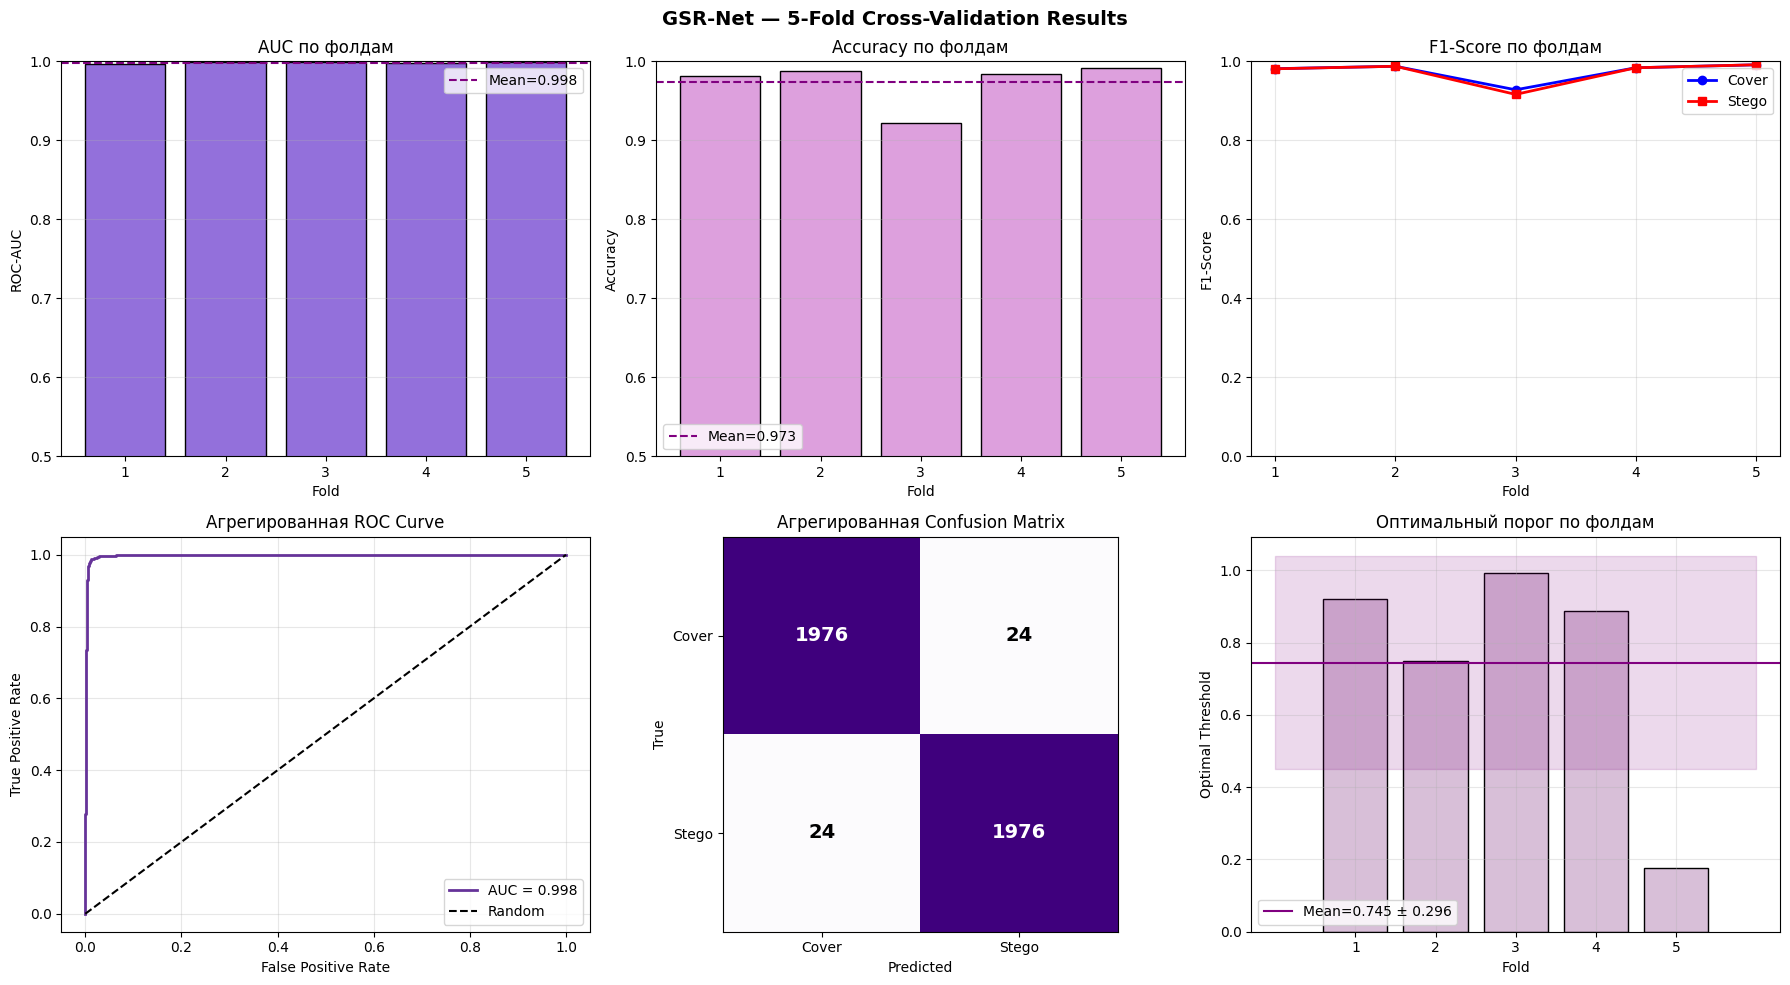


Финальные результаты сохранены: /content/drive/MyDrive/FQW/gsrnet2000/gsrnet_5fold_cv_results.json
Графики сохранены:              /content/drive/MyDrive/FQW/gsrnet2000/gsrnet_5fold_cv_results.png


In [9]:
# 7. Агрегация результатов и финальный отчёт

training_json_path = os.path.join(SAVE_DIR, 'gsrnet_5fold_cv_training_results.json')
with open(training_json_path, 'r') as f:
    cv_results_training = json.load(f)

fold_metrics = {
    key: [res[key] for res in cv_results_training['fold_results']]
    for key in cv_results_training['fold_results'][0]
    if key not in ['fold', 'optimal_threshold_at_best_auc']
}
all_fold_probs  = cv_results_training['aggregated_probs_and_labels']['probs']
all_fold_labels = cv_results_training['aggregated_probs_and_labels']['labels']

print('\n' + '='*60)
print(' АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV — GSRNet')
print('='*60)

for metric_name in ['auc', 'accuracy', 'f1_cover', 'f1_stego',
                    'precision_cover', 'precision_stego',
                    'recall_cover', 'recall_stego']:
    values   = fold_metrics[metric_name]
    mean_val = np.mean(values)
    std_val  = np.std(values)
    min_val  = np.min(values)
    max_val  = np.max(values)
    print(f'{metric_name.upper():<22s}: {mean_val:.4f} ± {std_val:.4f}  '
          f'[min={min_val:.4f}, max={max_val:.4f}]')

# Проверка на утечку данных
all_fold_labels_np = np.array(all_fold_labels)
all_fold_probs_np  = np.array(all_fold_probs)
y_shuffled         = np.random.permutation(all_fold_labels_np)
auc_random         = roc_auc_score(y_shuffled, all_fold_probs_np)
print(f'\nAUC на случайных лейблах (проверка утечки): {auc_random:.4f}')
print(f'(ожидается ~0.50; значительно выше → утечка данных)')

# Оптимальный порог на агрегированных данных
fpr_agg, tpr_agg, thr_agg = roc_curve(all_fold_labels_np, all_fold_probs_np)
optimal_threshold_agg = thr_agg[np.argmax(tpr_agg - fpr_agg)]
final_preds_agg = (all_fold_probs_np > optimal_threshold_agg).astype(int)

print(f'\nОбщий оптимальный порог (по всем фолдам): {optimal_threshold_agg:.4f}')
print('\nClassification Report (Aggregated, Optimal Threshold):')
print(classification_report(
    all_fold_labels_np, final_preds_agg,
    target_names=['Cover', 'Stego'], zero_division=0
))

cm_agg = confusion_matrix(all_fold_labels_np, final_preds_agg)
print('Confusion Matrix (Aggregated):')
print(cm_agg)

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('GSR-Net — 5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

# 1. AUC по фолдам
axes[0, 0].bar(range(1, N_FOLDS+1), fold_metrics['auc'], color='mediumpurple', edgecolor='black')
axes[0, 0].axhline(y=np.mean(fold_metrics['auc']), color='purple', linestyle='--',
                   label=f'Mean={np.mean(fold_metrics["auc"]):.3f}')
axes[0, 0].set_xlabel('Fold'); axes[0, 0].set_ylabel('ROC-AUC')
axes[0, 0].set_title('AUC по фолдам'); axes[0, 0].set_xticks(range(1, N_FOLDS+1))
axes[0, 0].legend(); axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0.5, 1.0])

# 2. Accuracy по фолдам
axes[0, 1].bar(range(1, N_FOLDS+1), fold_metrics['accuracy'], color='plum', edgecolor='black')
axes[0, 1].axhline(y=np.mean(fold_metrics['accuracy']), color='purple', linestyle='--',
                   label=f'Mean={np.mean(fold_metrics["accuracy"]):.3f}')
axes[0, 1].set_xlabel('Fold'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy по фолдам'); axes[0, 1].set_xticks(range(1, N_FOLDS+1))
axes[0, 1].legend(); axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0.5, 1.0])

# 3. F1-Score по фолдам
axes[0, 2].plot(range(1, N_FOLDS+1), fold_metrics['f1_cover'], 'b-o', label='Cover', linewidth=2)
axes[0, 2].plot(range(1, N_FOLDS+1), fold_metrics['f1_stego'], 'r-s', label='Stego', linewidth=2)
axes[0, 2].set_xlabel('Fold'); axes[0, 2].set_ylabel('F1-Score')
axes[0, 2].set_title('F1-Score по фолдам'); axes[0, 2].set_xticks(range(1, N_FOLDS+1))
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)
axes[0, 2].set_ylim([0.0, 1.0])

# 4. Агрегированная ROC-кривая
fpr_final, tpr_final, _ = roc_curve(all_fold_labels_np, all_fold_probs_np)
overall_auc = roc_auc_score(all_fold_labels_np, all_fold_probs_np)
axes[1, 0].plot(fpr_final, tpr_final, color='rebeccapurple', linewidth=2,
                label=f'AUC = {overall_auc:.3f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_xlabel('False Positive Rate'); axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Агрегированная ROC Curve')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# 5. Confusion Matrix
axes[1, 1].imshow(cm_agg, interpolation='nearest', cmap='Purples')
axes[1, 1].set_title('Агрегированная Confusion Matrix')
axes[1, 1].set_xlabel('Predicted'); axes[1, 1].set_ylabel('True')
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(['Cover', 'Stego'])
axes[1, 1].set_yticks([0, 1]); axes[1, 1].set_yticklabels(['Cover', 'Stego'])
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm_agg[i, j]), ha='center', va='center',
                        fontsize=14, fontweight='bold',
                        color='white' if cm_agg[i, j] > cm_agg.max()/2 else 'black')

# 6. Оптимальные пороги по фолдам
thresholds_per_fold = [res['optimal_threshold_at_best_auc']
                       for res in cv_results_training['fold_results']]
mean_thresh = np.mean(thresholds_per_fold)
std_thresh  = np.std(thresholds_per_fold)
axes[1, 2].bar(range(1, N_FOLDS+1), thresholds_per_fold, color='thistle', edgecolor='black')
axes[1, 2].axhline(y=mean_thresh, color='purple', linestyle='-',
                   label=f'Mean={mean_thresh:.3f} ± {std_thresh:.3f}')
axes[1, 2].fill_between(range(0, N_FOLDS+2),
                        mean_thresh - std_thresh, mean_thresh + std_thresh,
                        color='purple', alpha=0.15)
axes[1, 2].set_xlabel('Fold'); axes[1, 2].set_ylabel('Optimal Threshold')
axes[1, 2].set_title('Оптимальный порог по фолдам')
axes[1, 2].set_xticks(range(1, N_FOLDS+1))
axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
png_path = os.path.join(SAVE_DIR, 'gsrnet_5fold_cv_results.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()

# Сохранение финальных результатов в Google Drive
cv_results_final = {
    'n_folds':                  N_FOLDS,
    'unfreeze_epochs_per_fold': cv_results_training['unfreeze_epochs_per_fold'],
    'model_architecture':       cv_results_training['model_architecture'],
    'hyperparameters':          cv_results_training['hyperparameters'],
    'metrics': {
        'auc_mean':      float(np.mean(fold_metrics['auc'])),
        'auc_std':       float(np.std(fold_metrics['auc'])),
        'accuracy_mean': float(np.mean(fold_metrics['accuracy'])),
        'accuracy_std':  float(np.std(fold_metrics['accuracy'])),
        'f1_cover_mean': float(np.mean(fold_metrics['f1_cover'])),
        'f1_cover_std':  float(np.std(fold_metrics['f1_cover'])),
        'f1_stego_mean': float(np.mean(fold_metrics['f1_stego'])),
        'f1_stego_std':  float(np.std(fold_metrics['f1_stego'])),
    },
    'fold_details': cv_results_training['fold_results'],
    'aggregated': {
        'total_samples':             len(all_fold_labels_np),
        'overall_auc':               float(overall_auc),
        'overall_accuracy':          float(accuracy_score(all_fold_labels_np, final_preds_agg)),
        'overall_optimal_threshold': float(optimal_threshold_agg),
        'confusion_matrix':          cm_agg.tolist(),
    }
}

results_json_path = os.path.join(SAVE_DIR, 'gsrnet_5fold_cv_results.json')
with open(results_json_path, 'w') as f:
    json.dump(cv_results_final, f, indent=2)

print(f'\nФинальные результаты сохранены: {results_json_path}')
print(f'Графики сохранены:              {png_path}')
